# Load packages

In [1]:
import os
import random
from dataclasses import dataclass
from pathlib import Path
from anndata import AnnData

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scanpy as sc
import torch
import yaml

In [2]:
# Add parent directory to path
os.chdir("/workspace/src")

# Import STAIG
from staig.adata_processing import LoadBatch10xAdata, LoadSingle10xAdata
from staig.staig import STAIG

# Load data

In [3]:
# Define classes used thru script

@dataclass
class yml_config:
    dataset: str
    slide: str
    config: str
    label: bool

In [4]:
# Define the base "/Dataset" folder
data_path = Path("./Dataset")

args = yml_config(
    dataset="DLPFC",
    slide="151673",
    config="train_img_config.yaml",
    label=True,
)

# Load dataset configuration
config = yaml.load(Path(args.config).read_text(), Loader=yaml.SafeLoader)[
    int(args.slide)
]

# Path to targe slide
slide_path = data_path / args.dataset / args.slide
slide_path

PosixPath('Dataset/DLPFC/151673')

In [5]:
config

{'seed': 39788,
 'learning_rate': 0.0005,
 'num_hidden': 64,
 'num_proj_hidden': 64,
 'activation': 'prelu',
 'base_model': 'GCNConv',
 'num_layers': 1,
 'drop_feature_rate_1': 0.1,
 'drop_feature_rate_2': 0.2,
 'tau': 35,
 'num_epochs': 300,
 'weight_decay': 1e-05,
 'num_clusters': 7,
 'num_gene': 3000,
 'num_neigh': 5,
 'k': 80}

In [6]:
# Set seed from yaml_config file
torch.manual_seed(config["seed"])
np.random.seed(config["seed"])

# Set torch to deterministic for experiment reproducibility
if torch.cuda.is_available():
    torch.cuda.manual_seed(config["seed"])
    torch.cuda.manual_seed_all(config["seed"])
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
random.seed(config["seed"])

torch.use_deterministic_algorithms(True)

# Configure cuBLAS memory allocation to 4096MB 8 workspaces 
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

In [7]:
adata: AnnData = LoadSingle10xAdata(
    path=str(slide_path),
    n_neighbors=config["num_neigh"],
    n_top_genes=config["num_gene"],
    image_emb=True,
    label=args.label,
).run()

Calculating edge_probabilities: 100%|██████████| 3611/3611 [00:00<00:00, 75047.85it/s]

adata load done


# Data visualization

## Basic information

In [8]:
# Anndata object summary
print(adata)

AnnData object with n_obs × n_vars = 3611 × 33538
    obs: 'in_tissue', 'array_row', 'array_col', 'ground_truth'
    var: 'gene_ids', 'feature_types', 'genome', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'mean', 'std'
    uns: 'spatial', 'hvg', 'log1p'
    obsm: 'spatial', 'graph_neigh', 'feat', 'img_emb', 'feat_pca', 'con_feat', 'edge_probabilities'


In [9]:
# Peek into RNA information
print(adata.obs.head())

                    in_tissue  array_row  array_col ground_truth
AAACAAGTATCTCCCA-1          1         50        102      Layer_3
AAACAATCTACTAGCA-1          1          3         43      Layer_1
AAACACCAATAACTGC-1          1         59         19           WM
AAACAGAGCGACTCCT-1          1         14         94      Layer_3
AAACAGCTTTCAGAAG-1          1         43          9      Layer_5


In [10]:
# Available groupby options
print(adata.obs.columns.tolist())

# Gene name format
print(adata.var_names[:5])

# Check what obsm keys exist for neighbor graph
print(list(adata.obsm.keys()))

['in_tissue', 'array_row', 'array_col', 'ground_truth']
Index(['MIR1302-2HG', 'FAM138A', 'OR4F5', 'AL627309.1', 'AL627309.3'], dtype='object')
['spatial', 'graph_neigh', 'feat', 'img_emb', 'feat_pca', 'con_feat', 'edge_probabilities']


In [11]:
# Check index
print(adata.var_names[:3])

# Secondary ID format
print(adata.var['gene_ids'][:3])  

# # If your markers are symbols but var_names are Ensembl IDs, remap:
# adata.var_names_make_unique()
# gene_id_map = dict(zip(adata.var['gene_ids'], adata.var_names))

Index(['MIR1302-2HG', 'FAM138A', 'OR4F5'], dtype='object')
MIR1302-2HG    ENSG00000243485
FAM138A        ENSG00000237613
OR4F5          ENSG00000186092
Name: gene_ids, dtype: object


## Plotting functions

In [12]:
def plot_metrics(adata):
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    
    # Total counts per cell
    axes[0,0].hist(np.sum(adata.X, axis=1), bins=50)
    axes[0,0].set_title('Total UMI counts per cell')
    axes[0,0].set_xlabel('Counts')
    
    # Genes detected per cell
    axes[0,1].hist(np.sum(adata.X > 0, axis=1), bins=50)
    axes[0,1].set_title('Genes detected per cell')
    axes[0,1].set_xlabel('Number of genes')
    
    # Highly variable genes
    if 'highly_variable' in adata.var:
        hvg_counts = adata.var['highly_variable'].value_counts()
        axes[0,2].bar(hvg_counts.index, hvg_counts.values)
        axes[0,2].set_title('Highly Variable Genes')
    
    # Mean-variance relationship
    if 'means' in adata.var and 'variances' in adata.var:
        axes[1,0].scatter(adata.var['means'], adata.var['variances'], alpha=0.5, s=1)
        axes[1,0].set_xlabel('Mean expression')
        axes[1,0].set_ylabel('Variance')
        axes[1,0].set_title('Mean-Variance Relationship')
        axes[1,0].set_xscale('log')
        axes[1,0].set_yscale('log')
    
    # Top expressed genes
    gene_means = np.asarray(adata.X.mean(axis=0)).ravel()
    top_genes_idx = np.argsort(gene_means)[-20:]
    top_genes = np.array(adata.var_names)[top_genes_idx]
    top_means = gene_means[top_genes_idx]
    
    axes[1,1].barh(range(len(top_genes)), top_means)
    axes[1,1].set_yticks(range(len(top_genes)))
    axes[1,1].set_yticklabels(top_genes)
    axes[1,1].set_title('Top 20 Expressed Genes')
    
    # Gene detection rate distribution
    detection_rate = np.mean(adata.X > 0, axis=0)
    axes[1,2].hist(detection_rate.A1 if hasattr(detection_rate, 'A1') else detection_rate, bins=50)
    axes[1,2].set_title('Gene Detection Rate')
    axes[1,2].set_xlabel('Fraction of cells expressing gene')
    
    plt.tight_layout()
    return fig

In [13]:
from sklearn.decomposition import PCA

def plot_feature_embeddings(adata):
    """Visualize feature embeddings from obsm"""
    embedding_keys = ['feat', 'img_emb', 'con_feat']
    available_embeddings = [key for key in embedding_keys if key in adata.obsm]
    
    if not available_embeddings:
        print("No feature embeddings found")
        return
    
    n_embeddings = len(available_embeddings)
    fig, axes = plt.subplots(2, n_embeddings, figsize=(5*n_embeddings, 10))
    
    for idx, emb_key in enumerate(available_embeddings):
        emb_data = adata.obsm[emb_key]
        
        # Reduce to 2D for visualization if needed
        if emb_data.shape[1] > 2:
            pca = PCA(n_components=2)
            emb_2d = pca.fit_transform(emb_data)
            explained_var = pca.explained_variance_ratio_.sum()
        else:
            emb_2d = emb_data
            explained_var = 1.0
        
        # Scatter plot
        scatter = axes[0, idx].scatter(emb_2d[:, 0], emb_2d[:, 1],
                                      c=range(len(emb_2d)), cmap='viridis', s=5, alpha=0.7)
        axes[0, idx].set_title(f'{emb_key}\n(2D projection, var explained: {explained_var:.2f})')
        axes[0, idx].set_xlabel('Component 1')
        axes[0, idx].set_ylabel('Component 2')
        plt.colorbar(scatter, ax=axes[0, idx])
        
        # Colored by ground truth
        if 'ground_truth' in adata.obs:
            unique_labels = adata.obs['ground_truth'].unique()
            colors = plt.cm.tab20(np.linspace(0, 1, len(unique_labels)))
            
            for i, label in enumerate(unique_labels):
                mask = adata.obs['ground_truth'] == label
                axes[1, idx].scatter(emb_2d[mask, 0], emb_2d[mask, 1],
                                   color=colors[i], label=label, s=5, alpha=0.7)
            axes[1, idx].set_title(f'{emb_key} - by ground truth')
            axes[1, idx].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    
    plt.tight_layout()
    return fig

## Data plots

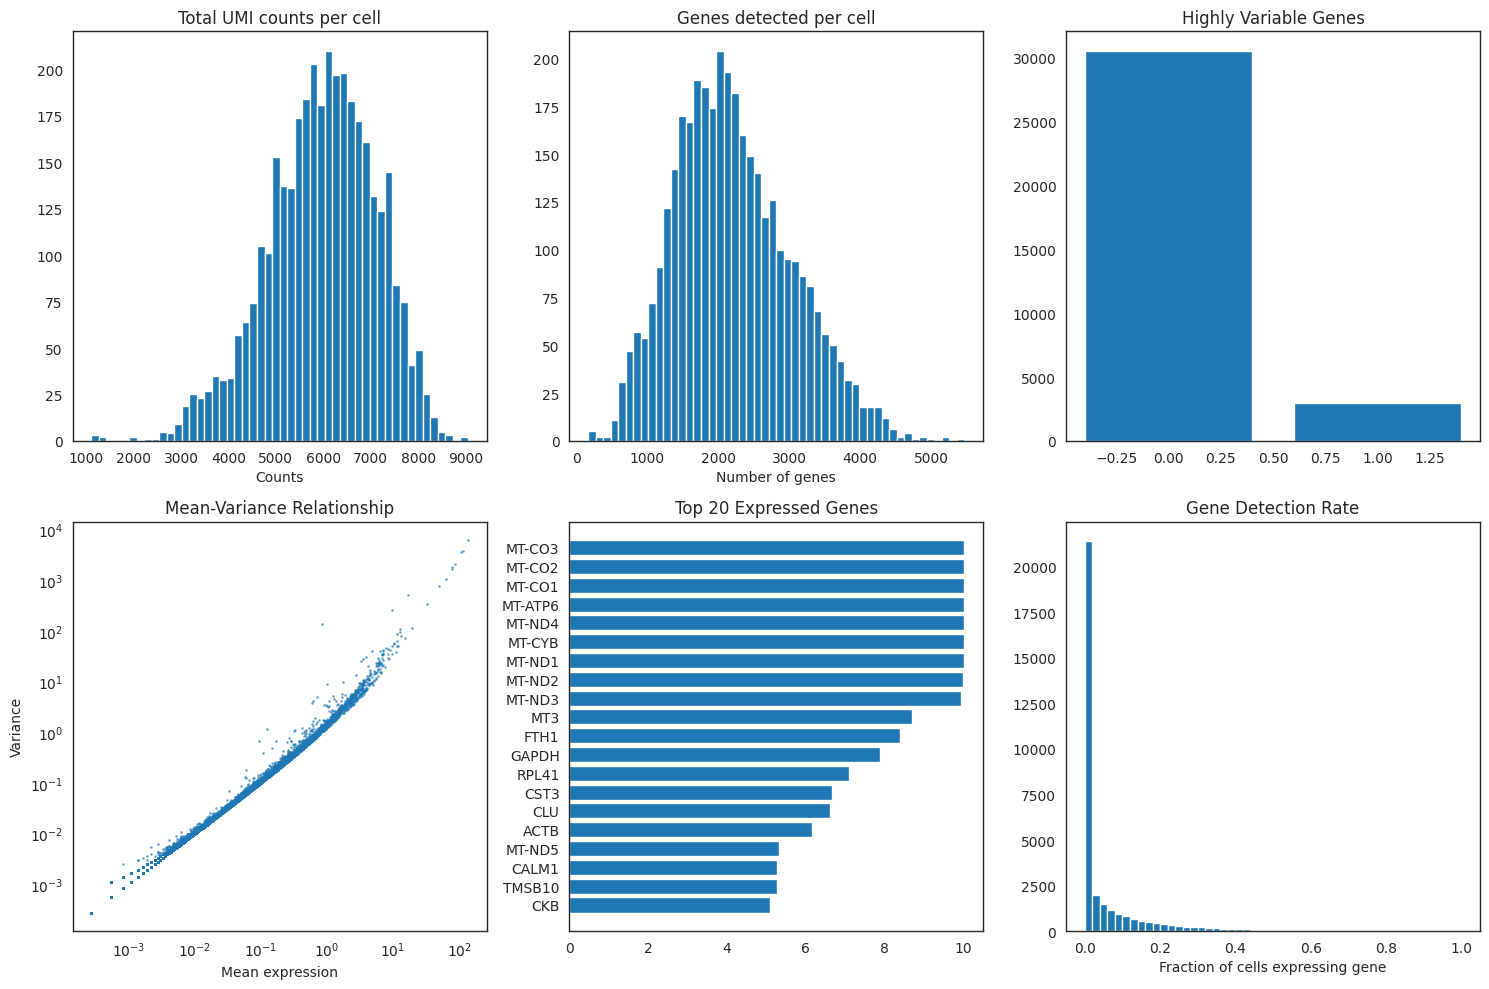

In [14]:
# Quality control metrics
plot_metrics(adata)
plt.show()

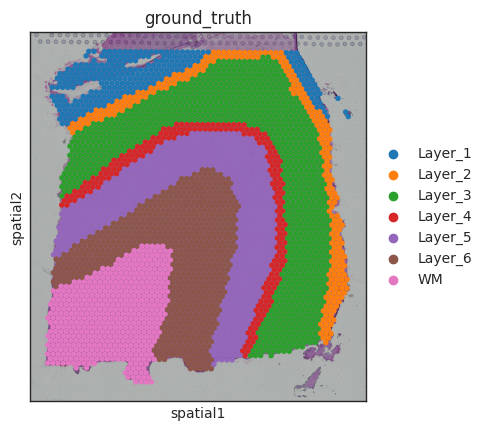

In [15]:
sc.pl.spatial(adata,
                     img_key='hires',
                     size=1.5,
                     color=['ground_truth']
)

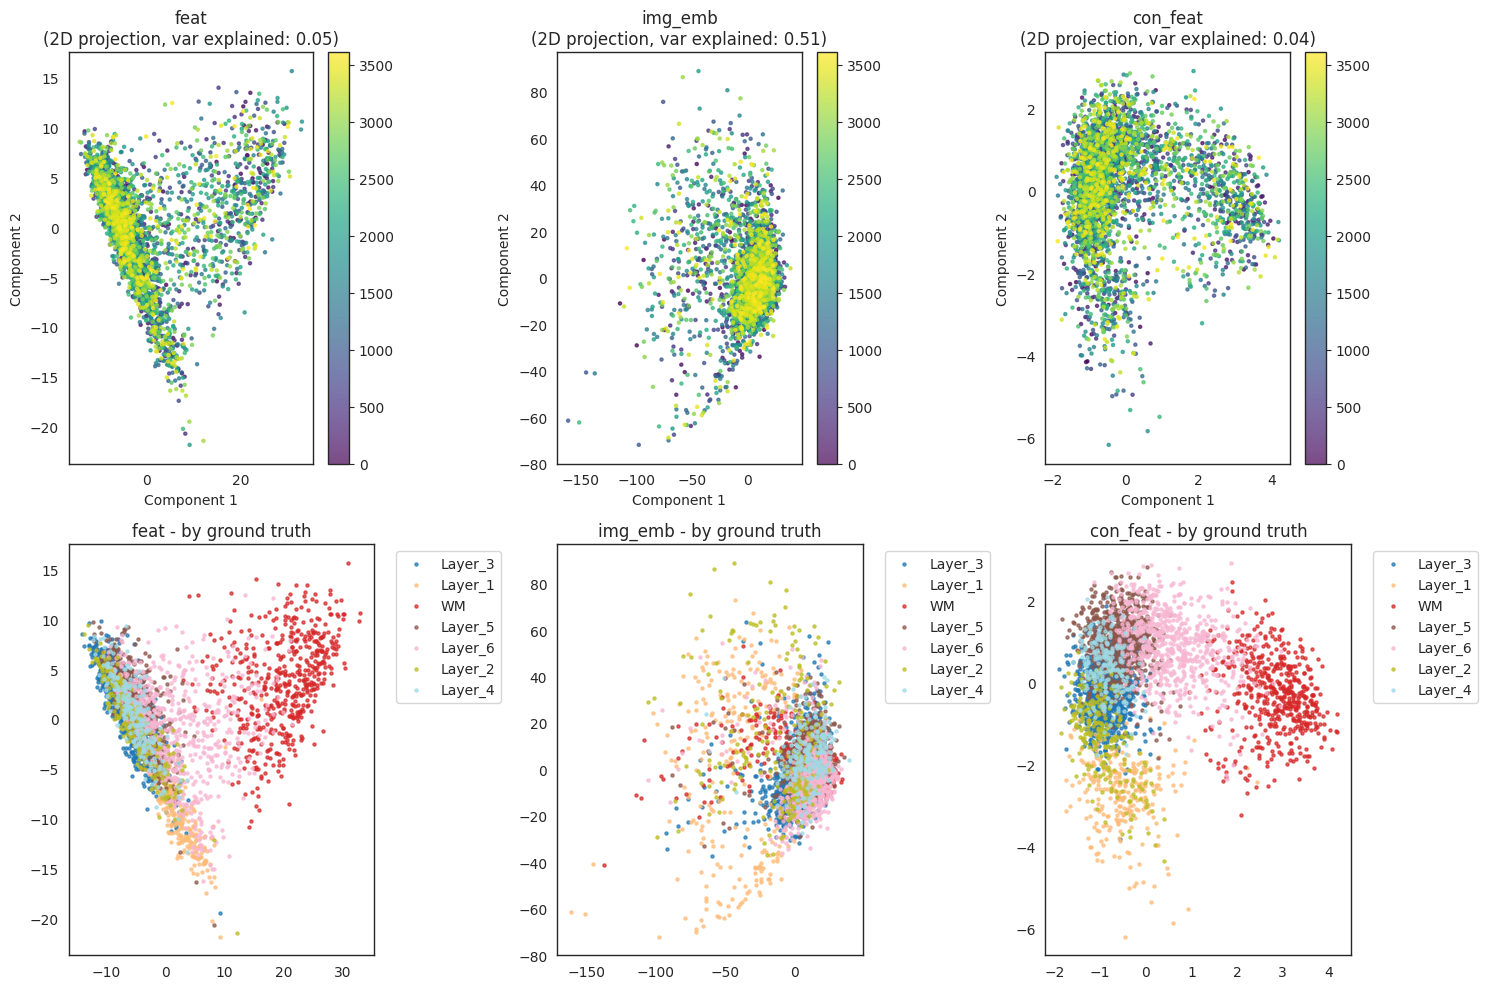

In [16]:
plot_feature_embeddings(adata)
plt.show()

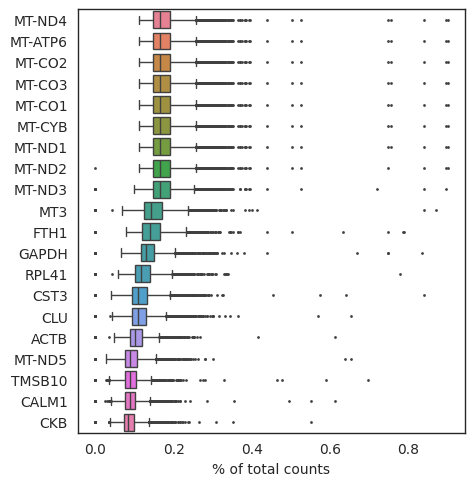

In [17]:
# Highest expressed genes
sc.pl.highest_expr_genes(adata, n_top=20)

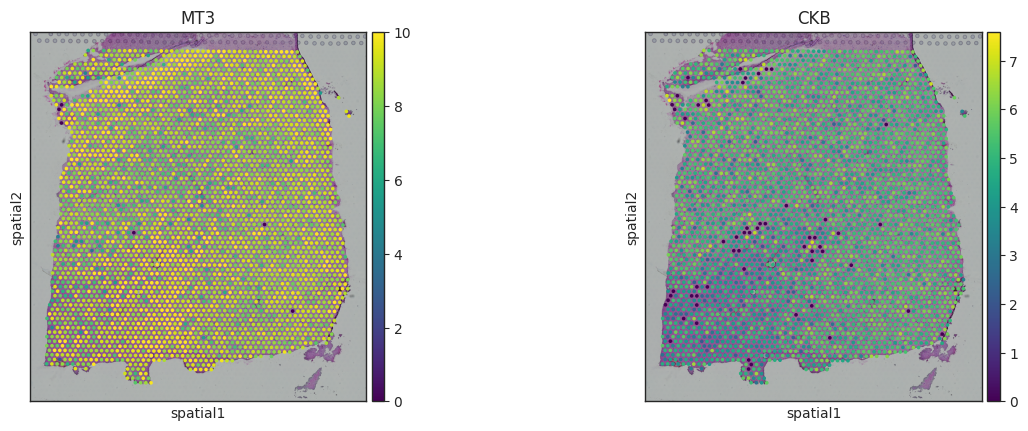

In [18]:
sc.pl.spatial(adata, color=['MT3', 'CKB'], ncols=2, color_map='viridis')

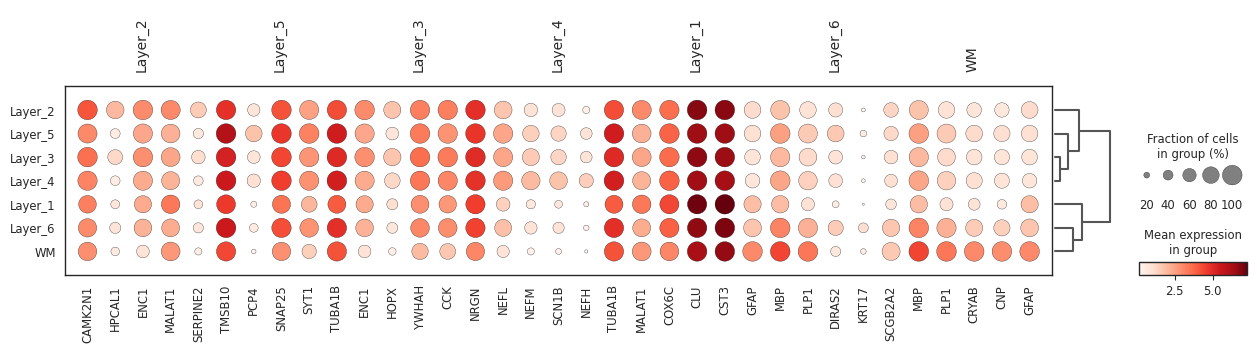

In [19]:
# First compute leiden if you haven't (see previous step)
sc.tl.rank_genes_groups(adata, groupby='ground_truth', method='wilcoxon')
sc.pl.rank_genes_groups_dotplot(adata, n_genes=5)  # top 5 markers per group

# Train

In [ ]:
# Set staig configuration from config_yml
staig = STAIG(args=args,config=config,single=False)   
staig.adata = adata

# Train model
staig.train()

=== prepare for training ===
=== train ===


100%|██████████| [00:30<00:00,  9.76it/s]


In [ ]:
def STAGM_train(data):
    if self.single is False:
            features_matrix = (
                torch.FloatTensor(self.adata.obsm["feat"].copy())
                .to(self.device)
                .double()
            )

            graph_neigh = (
                torch.FloatTensor(self.adata.obsm["graph_neigh"].copy())
                .to(self.device)
                .double()
            )
            edge_probabilities = (
                torch.FloatTensor(self.adata.obsm["edge_probabilities"].copy())
                .to(self.device)
                .double()
            )
            if "pseudo_labels" in self.adata.obs:
                pseudo_labels = torch.tensor(
                    self.adata.obs["pseudo_labels"].cat.codes
                ).to(self.device)
            else:
                if "k" in self.config:
                    pseudo_labels = generate_pseudo_labels(
                        self.adata.obsm["img_emb"], self.config["k"]
                    )
                else:
                    pseudo_labels = generate_pseudo_labels(self.adata.obsm["img_emb"])
                pseudo_labels = pseudo_labels.to(self.device)

In [21]:
# Eval model
staig.eva()

=== load ===
[[ 0.2075921  -1.25615679  1.26535297 ... -0.26969005  1.63045284
   0.64522385]
 [ 1.06281154 -0.67181526 -1.4921808  ...  0.34915463  0.29371755
  -0.92635168]
 [ 2.24652178  0.61298348 -6.29340476 ...  0.89626122 -2.45043674
  -3.54894611]
 ...
 [ 1.15355571  0.95955772 -3.45922494 ...  0.39314811 -1.81529311
  -1.83960711]
 [ 1.37189339  0.62630015 -3.97022725 ...  0.61635821 -1.62476285
  -2.11820022]
 [ 1.01259118 -2.05218119  0.61458097 ... -0.01207152  2.07655392
   0.18966501]]
embedding generated, go clustering


In [25]:
staig.cluster(args.label)

calculate metric ARI


KeyError: 'domain'

KeyError: 'Could not find key domain in .var_names or .obs.columns.'

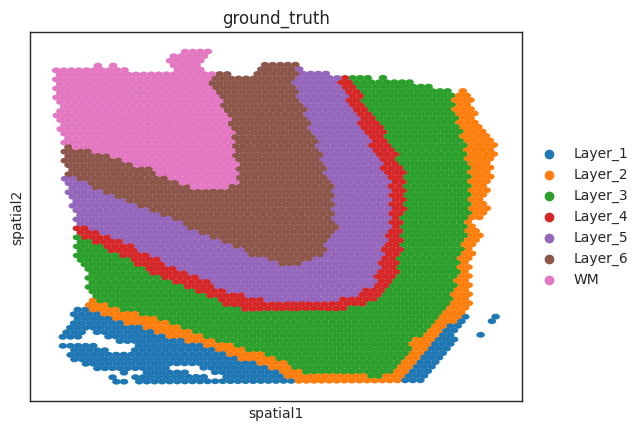

In [ ]:
staig.draw_spatial()